# Learning Objectives

- Build LLM applications for retrieval-augmented generation tasks.
- Index a folder of documents to a vector database

# Setup

In [1]:
!pip install -q tiktoken==0.6.0 \
                langchain==0.1.1 \
                sentence-transformers==2.3.1

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 76.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.

In [1]:
!pip install pypdf \
             chromadb \
             openai \
             langchain-community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95

In [1]:
from google.colab import userdata
import os
from openai import OpenAI
from google.colab import userdata # For secure API key handling

# Set your API key from Colab Secrets
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

client = OpenAI()

In [2]:
import json
import tiktoken
import gdown

import pandas as pd
# Wrong for your current pip installs
from langchain_text_splitters import RecursiveCharacterTextSplitter
#from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings.sentence_transformer import (
    SentenceTransformerEmbeddings
)
from langchain_community.vectorstores import Chroma

/tmp/ipykernel_6677/1967751661.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFDirectoryLoader


# Creating a Vector Database

## Download Raw Data

In [3]:
!unzip tesla-annual-reports.zip

Archive:  tesla-annual-reports.zip
   creating: tesla-annual-reports/
  inflating: tesla-annual-reports/tsla-20231231-gen.pdf  


## Chunking

Once the choice of embedding model is made, we can feed the input documents to the model. However, since there are multiple pages across documents (including figures, tables) we will need a method to parse individual portions of the document that is aligned with the embedding model.

We also know that the embedding model cannot process text beyond a fixed context length (512 tokens for `gte-large`). This roughly corresponds to about 400 words or about 1 page of text. With this limitation in mind, we will transform the pdf file into chunks of text that are no more than 512 characters long (this is a conservative choice from a token perspective). An alternative method would be to chunk the file by sections in the report (e.g., risk factors, legal proceedings, safety disclosures).

A common chunking strategy is to used a fixed-size chunk as defined by the embedding model and use a small overlap between the chunks (see figure below). Note that the chunk size is number of characters and not number of tokens.


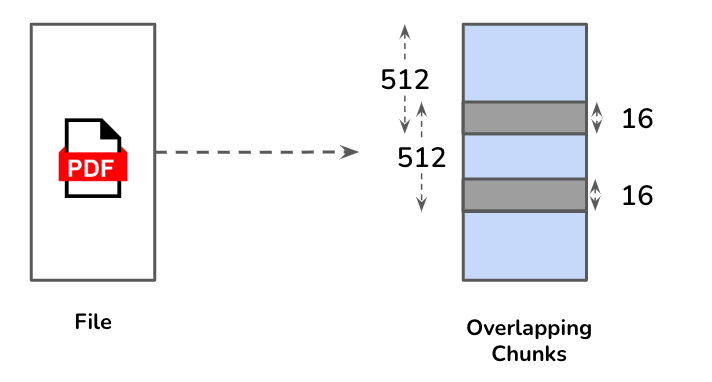

Using an overlap allows for continuity between chunks and retrieval of relevant chunks even when the information relevant to the query is present either at the beginning of the chunk or the end of the chunk.

In [5]:
pdf_folder_location = "tesla-annual-reports"

In [6]:
pdf_loader = PyPDFDirectoryLoader(pdf_folder_location)

In [7]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512,
    chunk_overlap=16
)

In [8]:
tesla_10k_chunks = pdf_loader.load_and_split(text_splitter)

In [9]:
len(tesla_10k_chunks)

351

In [10]:
tesla_10k_chunks

[Document(metadata={'producer': 'Qt 5.15.2', 'creator': 'wkhtmltopdf 0.12.6', 'creationdate': '2024-01-29T11:11:14+00:00', 'title': '', 'source': 'tesla-annual-reports/tsla-20231231-gen.pdf', 'total_pages': 130, 'page': 0, 'page_label': '1'}, page_content='UNITED\tSTATES\nSECURITIES\tAND\tEXCHANGE\tCOMMISSION\nWashington,\tD.C.\t20549\nFORM\t\n10-K\n(Mark\tOne)\nx\nANNUAL\tREPORT\tPURSUANT\tTO\tSECTION\t13\tOR\t15(d)\tOF\tTHE\tSECURITIES\tEXCHANGE\tACT\tOF\t1934\nFor\tthe\tfiscal\tyear\tended\t\nDecember\t31\n,\t2023\nOR\no\nTRANSITION\tREPORT\tPURSUANT\tTO\tSECTION\t13\tOR\t15(d)\tOF\tTHE\tSECURITIES\tEXCHANGE\tACT\tOF\t1934\nFor\tthe\ttransition\tperiod\tfrom\t_________\tto\t_________\nCommission\tFile\tNumber:\t\n001-34756\nTesla,\tInc.\n(Exact\tname\tof\tregistrant\tas\tspecified\tin\tits\tcharter)\nDelaware\n91-2197729\n(State\tor\tother\tjurisdiction\tof\nincorporation\tor\torganization)\n(I.R.S.\tEmployer\nIdentification\tNo.)\n1\tTesla\tRoad\nAustin\n,\t\nTexas\n78725\n(Address

## Database Creation

In [11]:
tesla_10k_collection = 'tesla-10k-2019-to-2023'

In [12]:
embedding_model = SentenceTransformerEmbeddings(model_name='thenlper/gte-large')

/tmp/ipykernel_6677/4198310515.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(model_name='thenlper/gte-large')


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.9k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [13]:
vectorstore = Chroma.from_documents(
    tesla_10k_chunks,
    embedding_model,
    collection_name=tesla_10k_collection,
    persist_directory='./tesla_db'
)

In [14]:
vectorstore.persist()

/tmp/ipykernel_6677/398866168.py:1: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


In [15]:
#Loading the Chroma DB and using the retriever to retreive the chunks just for testing

In [16]:
vectorstore_persisted = Chroma(
    collection_name=tesla_10k_collection,
    persist_directory='./tesla_db',
    embedding_function=embedding_model
)

/tmp/ipykernel_6677/377671238.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore_persisted = Chroma(


In [17]:
retriever = vectorstore_persisted.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

In [18]:
query = "What is the annual revenue in the year 2022 ?"

In [19]:
docs = vectorstore_persisted.similarity_search(query, k=5)

In [20]:
for i, doc in enumerate(docs):
    print(f"Retrieved chunk {i+1}: \n")
    print(doc.page_content.replace('\t', ' '))
    print('\n')

Retrieved chunk 1: 

Our cash flows provided by operating activities in 2023 and 2022 were $13.26 billion and $14.72 billion, respectively, representing a decrease of $1.47
billion. Capital expenditures amounted to $8.90 billion in 2023, compared to $7.16 billion in 2022, representing an increase of $1.74 billion. Sustained
growth has allowed our business to generally fund itself, and we will continue investing in a number of capital-intensive projects and research and
development in upcoming periods.
33


Retrieved chunk 2: 

Revenue Recognition
Revenue by source
The following table disaggregates our revenue by major source (in millions):
Year Ended December 31,
2023
2022
2021
Automotive sales
$
78,509
 
$
67,210
 
$
44,125
 
Automotive regulatory credits
1,790
 
1,776
 
1,465
 
Energy generation and storage sales
5,515
 
3,376
 
2,279
 
Services and other
8,319
 
6,091
 
3,802
 
Total revenues from sales and services
94,133
 
78,453
 
51,671
 
Automotive leasing
2,120
 
2,476
 
1,642

In [21]:
import json
import tiktoken

import pandas as pd

from openai import AzureOpenAI

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings.sentence_transformer import (
    SentenceTransformerEmbeddings
)
from langchain_community.vectorstores import Chroma

from google.colab import userdata

In [22]:
model_name='gpt-5.4-mini'

In [23]:
embedding_model = SentenceTransformerEmbeddings(model_name='thenlper/gte-large')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [24]:
tesla_10k_collection = 'tesla-10k-2019-to-2023'

In [25]:
vectorstore_persisted = Chroma(
    collection_name=tesla_10k_collection,
    persist_directory='./tesla_db',
    embedding_function=embedding_model
)

In [26]:
retriever = vectorstore_persisted.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

In [27]:
# Retrieve the first two chunks from the vector store
retrieved_data = vectorstore_persisted.get(
    include=['metadatas', 'embeddings', 'documents'],
    limit=2
)

# Display the content and embeddings of the first two chunks
for i in range(len(retrieved_data['ids'])):
    print(f"Chunk ID: {retrieved_data['ids'][i]}")
    print(f"Chunk Content: {retrieved_data['documents'][i]}")
    print(f"Chunk Embedding (first 10 values): {retrieved_data['embeddings'][i][:10]}")
    print("\n")

Chunk ID: 5083839c-3b62-4800-be10-4528dae4e232
Chunk Content: UNITED	STATES
SECURITIES	AND	EXCHANGE	COMMISSION
Washington,	D.C.	20549
FORM	
10-K
(Mark	One)
x
ANNUAL	REPORT	PURSUANT	TO	SECTION	13	OR	15(d)	OF	THE	SECURITIES	EXCHANGE	ACT	OF	1934
For	the	fiscal	year	ended	
December	31
,	2023
OR
o
TRANSITION	REPORT	PURSUANT	TO	SECTION	13	OR	15(d)	OF	THE	SECURITIES	EXCHANGE	ACT	OF	1934
For	the	transition	period	from	_________	to	_________
Commission	File	Number:	
001-34756
Tesla,	Inc.
(Exact	name	of	registrant	as	specified	in	its	charter)
Delaware
91-2197729
(State	or	other	jurisdiction	of
incorporation	or	organization)
(I.R.S.	Employer
Identification	No.)
1	Tesla	Road
Austin
,	
Texas
78725
(Address	of	principal	executive	offices)
(Zip	Code)
(
512
)	
516-8177
(Registrant’s	telephone	number,	including	area	code)
Securities	registered	pursuant	to	Section	12(b)	of	the	Act:
Title	of	each	class
Trading	Symbol(s)
Name	of	each	exchange	on	which	registered
Common	stock
TSLA
The	Nasdaq	Global	Select	

## RAG Q&A

### Prompt Design

In [28]:
qna_system_message = """
You are an assistant to a financial services firm who answers user queries on annual reports.
User input will have the context required by you to answer user questions.
This context will begin with the token: ###Context.
The context contains references to specific portions of a document relevant to the user query.

User questions will begin with the token: ###Question.

Please answer user questions only using the context provided in the input.
Do not mention anything about the context in your final answer. Your response should only contain the answer to the question.

If the answer is not found in the context, respond "I don't know".
"""

In [29]:
qna_user_message_template = """
###Context
Here are some documents that are relevant to the question mentioned below.
{context}

###Question
{question}
"""

### Retrieving relevant documents

In [30]:
user_input = "What is the annual revenue in the year 2022 ?"

In [31]:
relevant_document_chunks = retriever.invoke(user_input)

In [32]:
len(relevant_document_chunks)

5

In [33]:
for document in relevant_document_chunks:
    print(document.page_content.replace("\t", " "))
    break

Our cash flows provided by operating activities in 2023 and 2022 were $13.26 billion and $14.72 billion, respectively, representing a decrease of $1.47
billion. Capital expenditures amounted to $8.90 billion in 2023, compared to $7.16 billion in 2022, representing an increase of $1.74 billion. Sustained
growth has allowed our business to generally fund itself, and we will continue investing in a number of capital-intensive projects and research and
development in upcoming periods.
33


### Composing the response

In [34]:
user_input = "What is the annual revenues for the years 2022 and 2023 ? Also give me the total revenue across both these years"

In [35]:
relevant_document_chunks = retriever.invoke(user_input)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

prompt = [
    {'role':'system', 'content': qna_system_message},
    {'role': 'user', 'content': qna_user_message_template.format(
         context=context_for_query,
         question=user_input
        )
    }
]

print(prompt)
print()
try:
    response = client.chat.completions.create(
        model=model_name,
        messages=prompt,
        temperature=0
    )

    prediction = response.choices[0].message.content.strip()
except Exception as e:
    prediction = f'Sorry, I encountered the following error: \n {e}'

print(prediction)

[{'role': 'system', 'content': '\nYou are an assistant to a financial services firm who answers user queries on annual reports.\nUser input will have the context required by you to answer user questions.\nThis context will begin with the token: ###Context.\nThe context contains references to specific portions of a document relevant to the user query.\n\nUser questions will begin with the token: ###Question.\n\nPlease answer user questions only using the context provided in the input.\nDo not mention anything about the context in your final answer. Your response should only contain the answer to the question.\n\nIf the answer is not found in the context, respond "I don\'t know".\n'}, {'role': 'user', 'content': '\n###Context\nHere are some documents that are relevant to the question mentioned below.\nOur\tcash\tflows\tprovided\tby\toperating\tactivities\tin\t2023\tand\t2022\twere\t$13.26\tbillion\tand\t$14.72\tbillion,\trespectively,\trepresenting\ta\tdecrease\tof\t$1.47\nbillion.\tCapi

In [ ]:
prompt

[{'role': 'system',
  'content': '\nYou are an assistant to a financial services firm who answers user queries on annual reports.\nUser input will have the context required by you to answer user questions.\nThis context will begin with the token: ###Context.\nThe context contains references to specific portions of a document relevant to the user query.\n\nUser questions will begin with the token: ###Question.\n\nPlease answer user questions only using the context provided in the input.\nDo not mention anything about the context in your final answer. Your response should only contain the answer to the question.\n\nIf the answer is not found in the context, respond "I don\'t know".\n'},
 {'role': 'user',
  'content': '\n###Context\nHere are some documents that are relevant to the question mentioned below.\nOur\tcash\tflows\tprovided\tby\toperating\tactivities\tin\t2023\tand\t2022\twere\t$13.26\tbillion\tand\t$14.72\tbillion,\trespectively,\trepresenting\ta\tdecrease\tof\t$1.47\nbillion.\

## Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation. We illustrate this evaluation based on the answeres generated to the question from the previous section.

In [37]:
rater_model = 'gpt-5.4'

To save cost, we are using GPT 3.5 itself as the judge, the ideal choice would have been GPT 4 (note that this will impact the quality of the evaluation).

In [38]:
groundedness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer should be derived only from the information presented in the context

Instructions:
1. First write down the steps that are needed to evaluate the answer as per the metric.
2. Give a step-by-step explanation if the answer adheres to the metric considering the question and context as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the answer using the evaluaton criteria and assign a score.
"""

In [39]:
relevance_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
Relevance measures how well the answer addresses the main aspects of the question, based on the context.
Consider whether all and only the important aspects are contained in the answer when evaluating relevance.

Instructions:
1. First write down the steps that are needed to evaluate the context as per the metric.
2. Give a step-by-step explanation if the context adheres to the metric considering the question as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the context using the evaluaton criteria and assign a score.
"""

In [40]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [42]:
user_input = "What is the annual revenues for the years 2022 and 2023 ? Also give me the total revenue across both these years."

In [43]:
relevant_document_chunks = retriever.invoke(user_input)
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)

In [44]:
prompt = [
    {'role':'system', 'content': qna_system_message},
    {'role': 'user', 'content': qna_user_message_template.format(
         context=context_for_query,
         question=user_input
        )
    }
]

response = client.chat.completions.create(
    model=model_name,
    messages=prompt,
    temperature=0
)

answer = response.choices[0].message.content.strip()

In [45]:
print(answer)

2022 annual revenues were $81.46 billion, and 2023 annual revenues were $96.77 billion. The total revenue across both years was $178.23 billion.


In [46]:
groundedness_prompt = [
    {'role':'system', 'content': groundedness_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=answer
        )
    }
]

In [47]:
groundedness_prompt

[{'role': 'system',
  'content': '\nYou are tasked with rating AI generated answers to questions posed by users.\nYou will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.\nIn the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.\n\nEvaluation criteria:\nThe task is to judge the extent to which the metric is followed by the answer.\n1 - The metric is not followed at all\n2 - The metric is followed only to a limited extent\n3 - The metric is followed to a good extent\n4 - The metric is followed mostly\n5 - The metric is followed completely\n\nMetric:\nThe answer should be derived only from the information presented in the context\n\nInstructions:\n1. First write down the steps that are needed to evaluate the answer as per the metric.\n2. Give a step-by-step explanation if the answer adheres to the metric considering the q

In [48]:
response = client.chat.completions.create(
    model=rater_model,
    messages=groundedness_prompt,
    temperature=0
)

print(response.choices[0].message.content)

Steps to evaluate the answer as per the metric:
1. Identify the exact information requested in the question.
2. Locate the relevant revenue figures in the provided context.
3. Check whether the answer uses only those figures from the context.
4. Verify the arithmetic for the total across 2022 and 2023.
5. Determine whether any part of the answer introduces information not supported by the context.

Step-by-step evaluation:
1. The question asks for annual revenues for 2022 and 2023, and the total revenue across both years.
2. In the context, it explicitly states: “In 2023, we recognized total revenues of $96.77 billion, representing an increase of $15.31 billion, compared to the prior year.”
3. From this, 2023 revenue is directly given as $96.77 billion.
4. Since 2023 revenue increased by $15.31 billion over 2022, 2022 revenue can be derived as:
   - $96.77 billion - $15.31 billion = $81.46 billion
5. The total across both years is:
   - $96.77 billion + $81.46 billion = $178.23 billion

In [49]:
relevance_prompt = [
    {'role':'system', 'content': relevance_rater_system_message},
    {'role': 'user', 'content': user_message_template.format(
        question=user_input,
        context=context_for_query,
        answer=answer
        )
    }
]

In [50]:
response = client.chat.completions.create(
    model=rater_model,
    messages=relevance_prompt,
    temperature=0
)

print(response.choices[0].message.content)

1. Identify the exact information requested in the question: annual revenues for 2022 and 2023, plus the combined total across both years.  
2. Check the context for explicit revenue figures for 2023 and any information that allows deriving 2022 revenue.  
3. Verify whether the answer includes both yearly revenues and the summed total.  
4. Confirm the numbers are consistent with the context and that no irrelevant information is added.  
5. Rate how completely the answer addresses the question based on the context.

Step-by-step evaluation:
1. The question asks for annual revenues in 2022 and 2023, and the total across both years.  
2. The context explicitly states: “In 2023, we recognized total revenues of $96.77 billion, representing an increase of $15.31 billion, compared to the prior year.”  
3. From this, 2022 revenue can be derived as $96.77 billion - $15.31 billion = $81.46 billion.  
4. The answer states 2022 annual revenues were $81.46 billion and 2023 annual revenues were $96

In [36]:
import gradio as gr

def rag_assistant(question):
    """
    Wraps the RAG logic: retrieves relevant chunks, formats the prompt,
    and calls the LLM for a response.
    """
    try:
        # 1. Retrieve relevant documents
        relevant_chunks = retriever.invoke(question)
        context_list = [d.page_content for d in relevant_chunks]
        context_for_query = ". ".join(context_list)

        # 2. Prepare the prompt using existing templates
        prompt = [
            {'role': 'system', 'content': qna_system_message},
            {'role': 'user', 'content': qna_user_message_template.format(
                context=context_for_query,
                question=question
            )}
        ]

        # 3. Generate response via OpenAI client
        response = client.chat.completions.create(
            model=model_name,
            messages=prompt,
            temperature=0
        )

        return response.choices[0].message.content.strip()

    except Exception as e:
        return f"Error: {str(e)}"

# Create the Gradio interface
with gr.Blocks() as demo:
    gr.Markdown("# Tesla 10-K RAG Assistant")
    gr.Markdown("Ask questions about Tesla's annual reports based on the indexed data.")

    with gr.Row():
        input_text = gr.Textbox(label="Your Question", placeholder="e.g., What was the revenue in 2022?")
        output_text = gr.Textbox(label="Assistant Response")

    submit_btn = gr.Button("Ask Assistant")
    submit_btn.click(fn=rag_assistant, inputs=input_text, outputs=output_text)

# Launch the app
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e17cde067a08d7220.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
